### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.decomposition import PCA
from hebbian.utils import generate_covariance_matrix

from hebbian.utils import instantiate_samples_by_cov, rotation_matrix_nd


In [2]:
N = 128
m = 4
phi_deg = 75.0
n_samples = 10001
X_seed = 0
# get /sigma
# eigenvalues = np.array([2.0, 0.8])  # Your desired eigenvalues
eigenvalues = np.array([3.0, 2.9, 1.0, 0.4])
# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

R = rotation_matrix_nd(m, axis1=0, axis2=1, phi_rad=np.deg2rad(phi_deg))
Sigma_rot = R @ Sigma @ R.T

X_before = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)
X_after = instantiate_samples_by_cov(Sigma_rot, N, m, seed=X_seed, n_samples=n_samples)

# B. Generate Data (Rotate 45 degrees), if I want to purely rotate the data,
# but usually we want to simulate the data based on the rotated covariance matrix,
# so discard it:
# X_before, X_after = instantiate_rotated_data(N, m, Sigma, phi_rad=np.deg2rad(phi_deg), seed=X_seed, n_samples=n_samples)


# Do PCA on X before and X after
pca_before = PCA(n_components=m)
pca_before.fit(X_before)
X_before_pca = pca_before.transform(X_before)
pca_after = PCA(n_components=m)
pca_after.fit(X_after)
X_after_pca = pca_after.transform(X_after)

# eigen values of X before and X after
print(f"Eigen values of X before: {pca_before.explained_variance_}")
print(f"Eigen values of X after: {pca_after.explained_variance_}")

# variance explained by each PC
print(f"Variance explained by each PC of X before: {pca_before.explained_variance_ratio_}")
print(f"Variance explained by each PC of X after: {pca_after.explained_variance_ratio_}")



Eigen values of X before: [3.01455695 2.87761369 1.00754574 0.4037465 ]
Eigen values of X after: [3.01455695 2.87761369 1.00754574 0.4037465 ]
Variance explained by each PC of X before: [0.41275721 0.39400675 0.13795452 0.05528152]
Variance explained by each PC of X after: [0.41275721 0.39400675 0.13795452 0.05528152]


### Apply Leen's complete model to before and after drifted models

### Multiple runs

In [3]:
from hebbian.utils import two_phase_training_testing

### Leen's complete model

In [14]:
from hebbian.models import OneShotLeenCompletePCA, OneShotLeenFreislebenPCA, SangerNetwork, LeenCompletePCA, LeenCompletePCA_TD, OjaNetwork
# runs = 10
model_paras = dict(
    input_size=N, output_size=m,
    eta_w=1e-4,          # base
    eta_v=1e-3,          # ~4x eta_w
    C=2,
    # ema_alpha=0.05,
    symmetrize_V=True,
    seed=None,
    # noise_level=0.001,
    # settling_steps=10
)


_model_paras = dict(
    input_size=N, output_size=m,
    eta_w=1e-4,          # base
    eta_v=1e-3,          # ~4x eta_w
    C=1.0,
    # ema_alpha=0.05,
    symmetrize_V=True,
    seed=None,
    # noise_level=0.001,
    # # settling_steps=10
)



model_paras_after = dict(
    eta_w=5e-4,
    eta_v=5e-3,
#     eta_w=6e-5,          # base
#     eta_v=5e-4,          # ~4x eta_w
)

run  1
X_before
step    0 | order = [3 0 2 1] | best|corr|= [0.105 0.076 0.085 0.092]
step 1000 | order = [3 0 2 1] | best|corr|= [0.114 0.115 0.099 0.127]
step 2000 | order = [3 0 2 1] | best|corr|= [0.128 0.167 0.112 0.176]
step 3000 | order = [3 0 2 1] | best|corr|= [0.145 0.193 0.12  0.241]
step 4000 | order = [3 0 2 1] | best|corr|= [0.16  0.171 0.127 0.299]
step 5000 | order = [3 0 2 1] | best|corr|= [0.18  0.138 0.141 0.395]
step 6000 | order = [0 3 2 1] | best|corr|= [0.136 0.17  0.166 0.515]
step 7000 | order = [0 3 2 1] | best|corr|= [0.141 0.194 0.193 0.606]
step 8000 | order = [0 3 2 1] | best|corr|= [0.172 0.218 0.203 0.698]
step 9000 | order = [0 3 2 1] | best|corr|= [0.213 0.236 0.188 0.798]
step 10000 | order = [0 3 2 1] | best|corr|= [0.284 0.247 0.152 0.876]


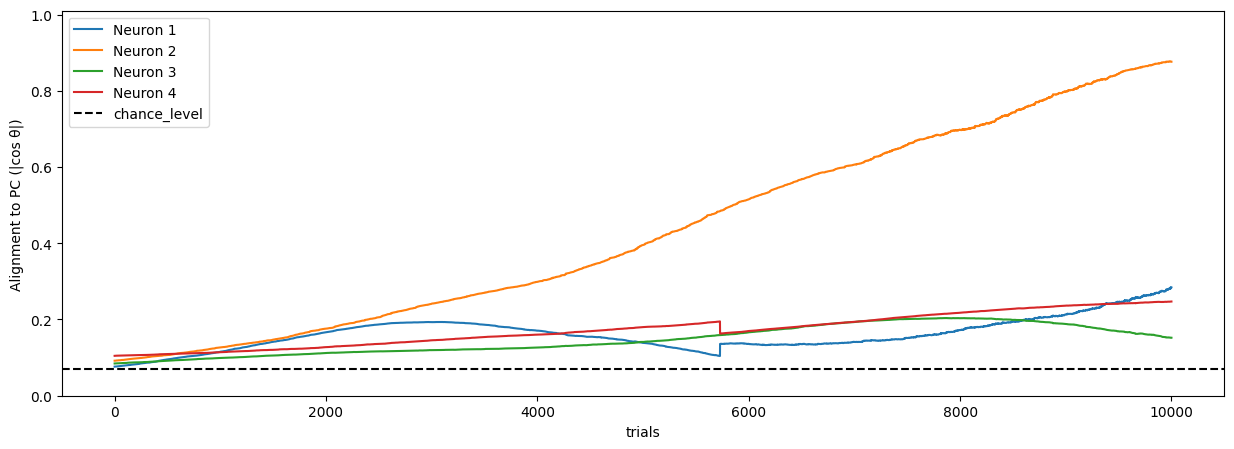

X_after
step    0 | order = [0 3 2 1] | best|corr|= [0.312 0.256 0.117 0.654]
step 1000 | order = [0 3 2 1] | best|corr|= [0.383 0.299 0.223 0.683]
step 2000 | order = [0 3 2 1] | best|corr|= [0.372 0.304 0.236 0.728]
step 3000 | order = [0 2 3 1] | best|corr|= [0.484 0.428 0.055 0.699]
step 4000 | order = [0 2 3 1] | best|corr|= [0.462 0.454 0.092 0.784]
step 5000 | order = [0 2 3 1] | best|corr|= [0.615 0.467 0.119 0.713]
step 6000 | order = [0 2 3 1] | best|corr|= [0.602 0.474 0.134 0.775]
step 7000 | order = [0 2 3 1] | best|corr|= [0.64  0.502 0.141 0.767]
step 8000 | order = [0 2 3 1] | best|corr|= [0.667 0.538 0.143 0.76 ]
step 9000 | order = [0 2 3 1] | best|corr|= [0.687 0.576 0.138 0.752]
step 10000 | order = [0 2 3 1] | best|corr|= [0.71  0.623 0.126 0.746]


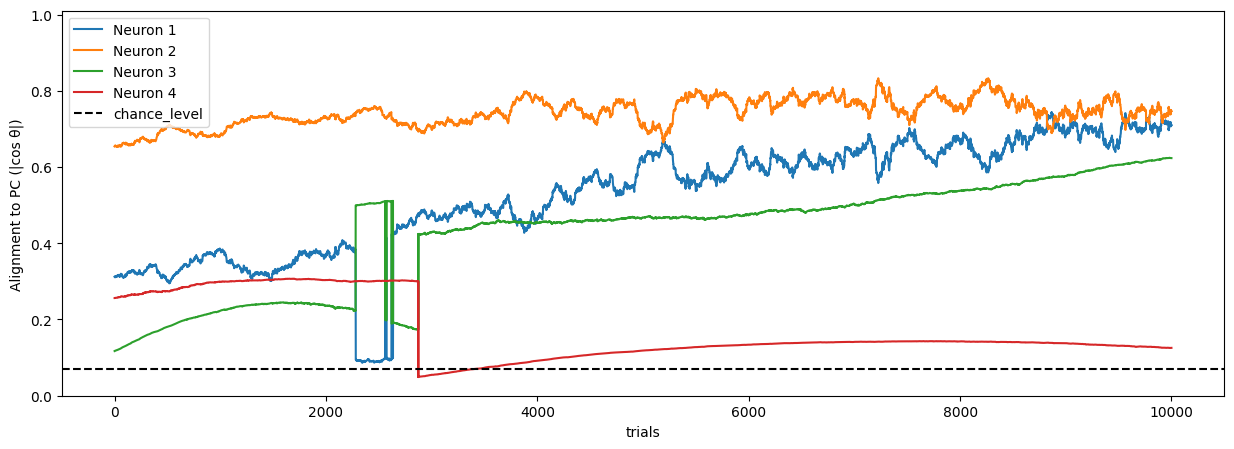

run  2
X_before
step    0 | order = [3 0 2 1] | best|corr|= [0.191 0.022 0.132 0.052]
step 1000 | order = [3 0 2 1] | best|corr|= [0.2   0.031 0.142 0.075]
step 2000 | order = [3 0 2 1] | best|corr|= [0.211 0.036 0.148 0.105]
step 3000 | order = [3 0 2 1] | best|corr|= [0.22  0.028 0.151 0.144]
step 4000 | order = [0 1 2 3] | best|corr|= [0.123 0.157 0.153 0.187]
step 5000 | order = [0 1 2 3] | best|corr|= [0.136 0.209 0.169 0.214]
step 6000 | order = [3 2 0 1] | best|corr|= [0.234 0.211 0.085 0.295]
step 7000 | order = [3 2 0 1] | best|corr|= [0.235 0.284 0.065 0.265]
step 8000 | order = [0 2 1 3] | best|corr|= [0.185 0.336 0.097 0.249]
step 9000 | order = [0 2 1 3] | best|corr|= [0.223 0.353 0.103 0.227]
step 10000 | order = [0 2 3 1] | best|corr|= [0.363 0.339 0.06  0.359]


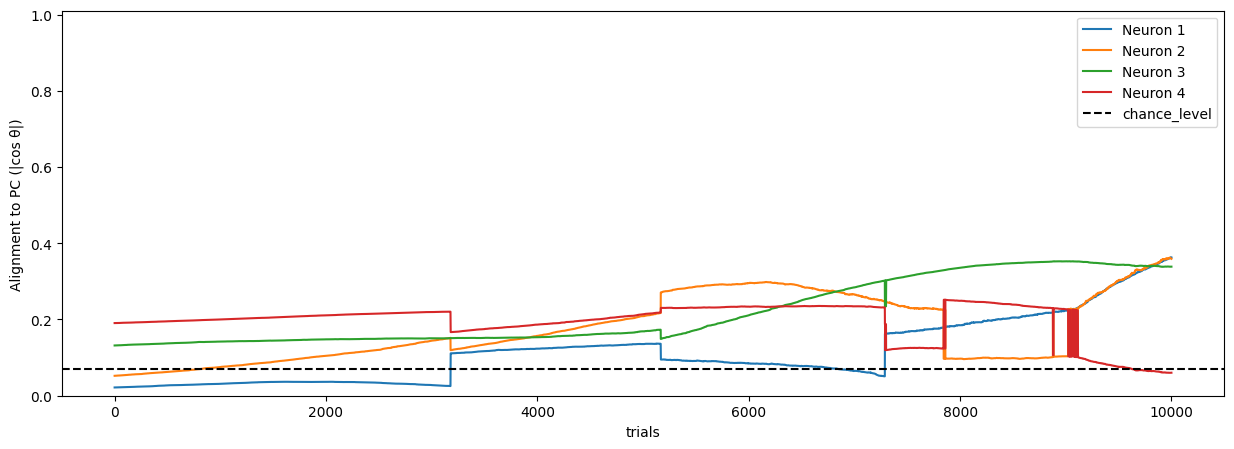

X_after
step    0 | order = [3 2 1 0] | best|corr|= [0.284 0.198 0.161 0.476]
step 1000 | order = [3 1 2 0] | best|corr|= [0.313 0.241 0.135 0.568]
step 2000 | order = [2 1 3 0] | best|corr|= [0.394 0.254 0.094 0.675]
step 3000 | order = [2 1 3 0] | best|corr|= [0.416 0.287 0.087 0.759]
step 4000 | order = [2 1 3 0] | best|corr|= [0.434 0.354 0.073 0.817]
step 5000 | order = [2 1 3 0] | best|corr|= [0.443 0.437 0.053 0.869]
step 6000 | order = [2 1 3 0] | best|corr|= [0.45  0.559 0.027 0.874]
step 7000 | order = [2 1 3 0] | best|corr|= [0.458 0.653 0.001 0.887]
step 8000 | order = [2 1 3 0] | best|corr|= [0.461 0.757 0.03  0.904]
step 9000 | order = [2 1 3 0] | best|corr|= [0.431 0.829 0.089 0.913]
step 10000 | order = [2 1 3 0] | best|corr|= [0.402 0.879 0.14  0.909]


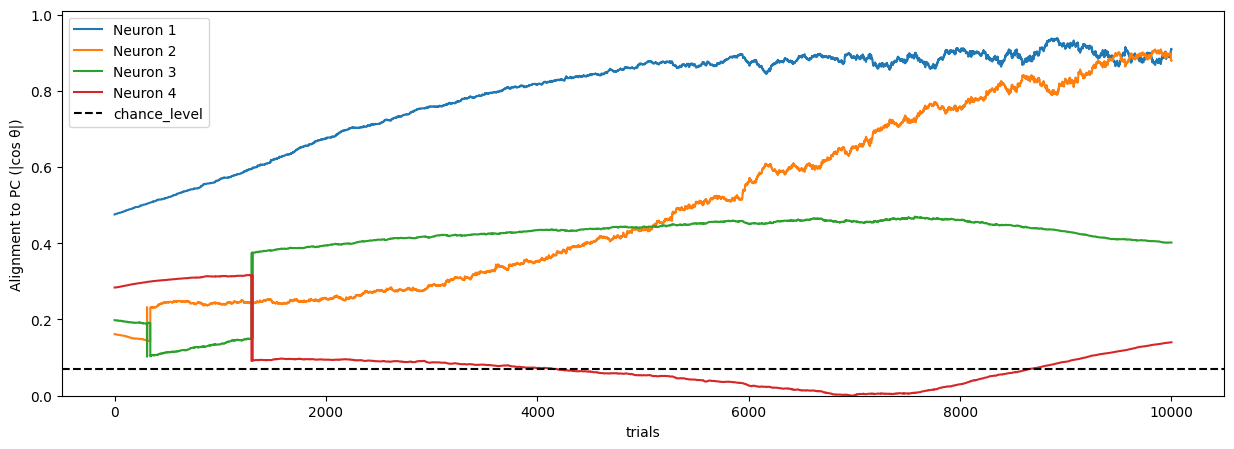

<Figure size 640x480 with 0 Axes>

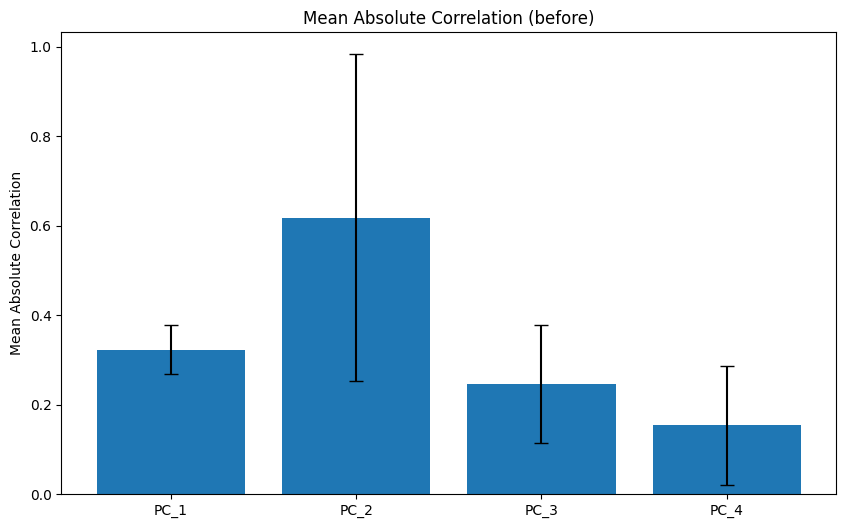

<Figure size 640x480 with 0 Axes>

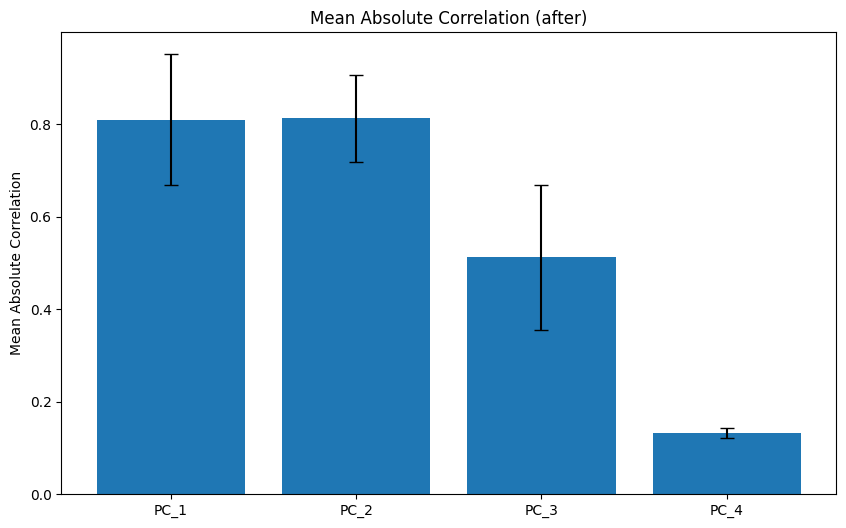

In [16]:
leen_model  = OneShotLeenCompletePCA(**model_paras)
# leen_model = LeenCompletePCA(**model_paras)
# leen_model = LeenCompletePCA_TD(**_model_paras)
# leen_model = OneShotLeenFreislebenPCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, 
                            # model_paras_after = model_paras_after, 
                            runs = 2, graph = True)

### Golden standard: Sanger's rule

run  1
X_before
step    0 | order = [2 0 1 3] | best|corr|= [0.061 0.246 0.115 0.086]
step 1000 | order = [2 0 3 1] | best|corr|= [0.074 0.976 0.061 0.744]
step 2000 | order = [0 2 1 3] | best|corr|= [0.975 0.019 0.986 0.038]
step 3000 | order = [0 1 2 3] | best|corr|= [0.938 0.953 0.101 0.023]
step 4000 | order = [0 1 2 3] | best|corr|= [0.963 0.945 0.212 0.015]
step 5000 | order = [0 1 2 3] | best|corr|= [0.957 0.957 0.452 0.053]
step 6000 | order = [0 1 2 3] | best|corr|= [0.981 0.974 0.778 0.068]
step 7000 | order = [0 1 2 3] | best|corr|= [0.989 0.984 0.953 0.066]
step 8000 | order = [0 1 2 3] | best|corr|= [0.982 0.979 0.994 0.027]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.985 0.999 0.041]
step 10000 | order = [0 1 2 3] | best|corr|= [0.956 0.965 1.    0.075]


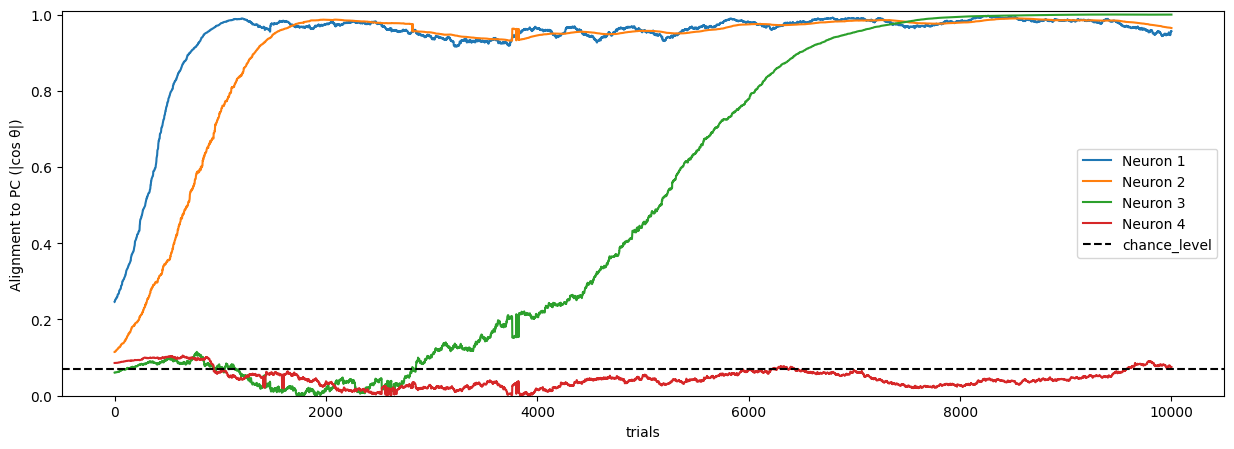

X_after
step    0 | order = [2 1 3 0] | best|corr|= [0.761 0.829 0.176 0.76 ]
step 1000 | order = [0 1 3 2] | best|corr|= [0.967 0.965 0.191 0.727]
step 2000 | order = [0 1 3 2] | best|corr|= [0.968 0.968 0.153 0.925]
step 3000 | order = [0 1 2 3] | best|corr|= [0.975 0.977 0.975 0.134]
step 4000 | order = [0 1 2 3] | best|corr|= [0.972 0.976 0.997 0.24 ]
step 5000 | order = [0 1 2 3] | best|corr|= [0.967 0.976 0.999 0.348]
step 6000 | order = [0 1 2 3] | best|corr|= [0.968 0.963 0.999 0.466]
step 7000 | order = [0 1 2 3] | best|corr|= [0.982 0.98  0.999 0.625]
step 8000 | order = [0 1 2 3] | best|corr|= [0.994 0.997 1.    0.784]
step 9000 | order = [0 1 2 3] | best|corr|= [0.998 0.998 1.    0.888]
step 10000 | order = [0 1 2 3] | best|corr|= [0.995 0.998 1.    0.945]


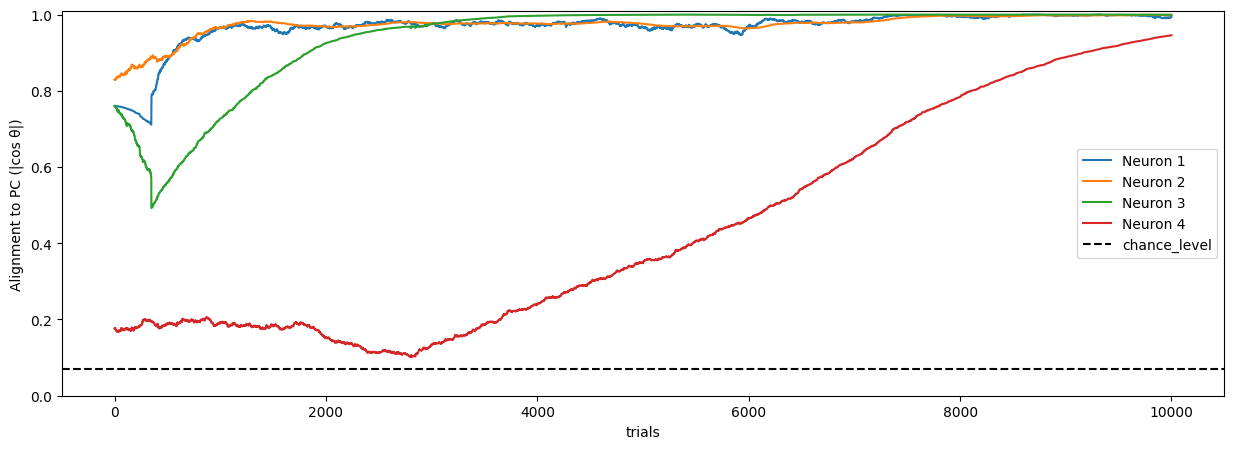

run  2
X_before
step    0 | order = [0 1 2 3] | best|corr|= [0.119 0.085 0.1   0.099]
step 1000 | order = [0 1 2 3] | best|corr|= [0.872 0.773 0.268 0.071]
step 2000 | order = [0 1 2 3] | best|corr|= [0.999 0.998 0.334 0.023]
step 3000 | order = [0 1 2 3] | best|corr|= [0.99  0.995 0.625 0.02 ]
step 4000 | order = [0 1 2 3] | best|corr|= [0.996 0.991 0.895 0.012]
step 5000 | order = [0 1 2 3] | best|corr|= [0.996 0.995 0.983 0.014]
step 6000 | order = [0 1 2 3] | best|corr|= [1.    0.999 0.998 0.036]
step 7000 | order = [0 1 2 3] | best|corr|= [1.    0.999 1.    0.045]
step 8000 | order = [0 1 2 3] | best|corr|= [0.995 0.995 1.    0.024]
step 9000 | order = [0 1 2 3] | best|corr|= [0.995 0.996 1.    0.042]
step 10000 | order = [0 1 2 3] | best|corr|= [0.975 0.982 1.    0.072]


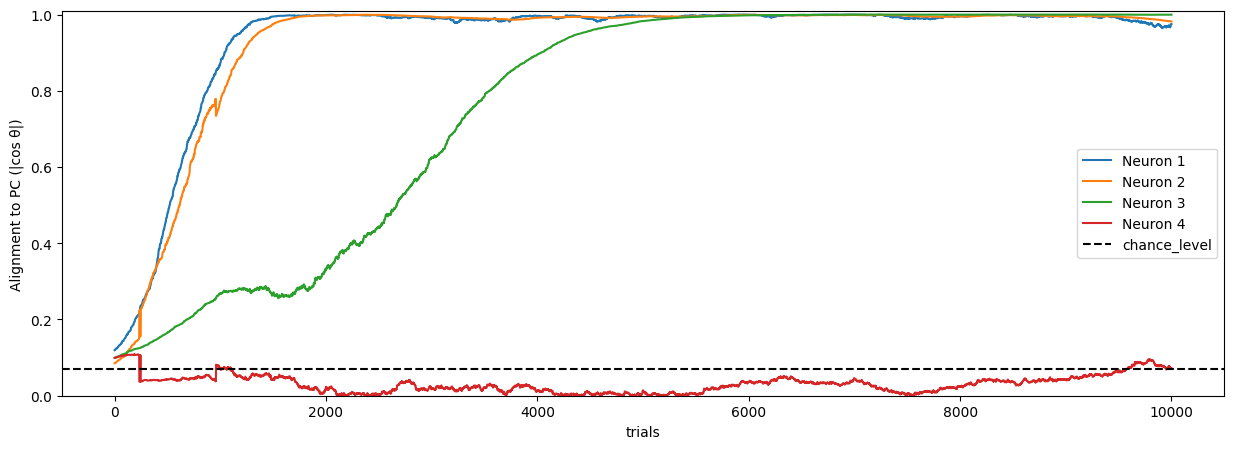

X_after
step    0 | order = [2 1 0 3] | best|corr|= [0.779 0.834 0.733 0.243]
step 1000 | order = [0 1 3 2] | best|corr|= [0.972 0.967 0.194 0.88 ]
step 2000 | order = [0 1 3 2] | best|corr|= [0.979 0.98  0.153 0.985]
step 3000 | order = [0 1 3 2] | best|corr|= [0.988 0.988 0.081 0.987]
step 4000 | order = [0 1 2 3] | best|corr|= [0.984 0.988 0.997 0.139]
step 5000 | order = [0 1 2 3] | best|corr|= [0.981 0.987 0.999 0.216]
step 6000 | order = [0 1 2 3] | best|corr|= [0.979 0.977 0.999 0.293]
step 7000 | order = [0 1 2 3] | best|corr|= [0.988 0.987 0.999 0.43 ]
step 8000 | order = [0 1 2 3] | best|corr|= [0.996 0.999 1.    0.611]
step 9000 | order = [0 1 2 3] | best|corr|= [0.999 0.999 1.    0.762]
step 10000 | order = [0 1 2 3] | best|corr|= [0.992 0.996 1.    0.867]


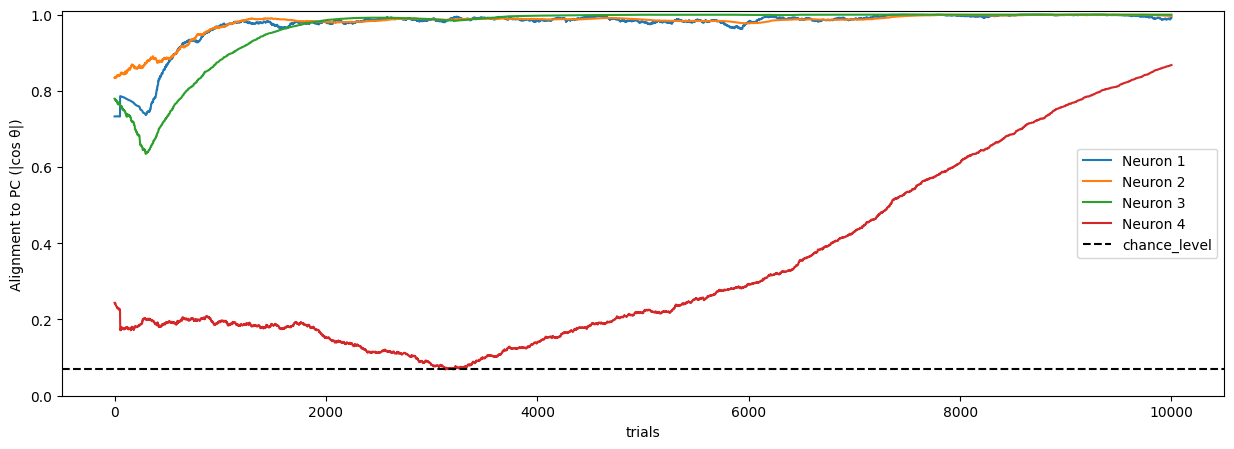

run  3
X_before
step    0 | order = [0 2 3 1] | best|corr|= [0.146 0.172 0.134 0.08 ]
step 1000 | order = [0 2 3 1] | best|corr|= [0.881 0.233 0.122 0.699]
step 2000 | order = [0 2 3 1] | best|corr|= [0.992 0.242 0.065 0.99 ]


KeyboardInterrupt: 

In [7]:
sanger_model = SangerNetwork(output_size=m, learning_rate=0.001, rng=None)

sanger_model_after = dict(learning_rate=0.001)

two_phase_training_testing(sanger_model, data_before=X_before, data_after=X_after, m=m, model_paras_after = sanger_model_after, runs = 10, graph = True)

### decoding task variable

In [ ]:
from hebbian.utils import pca_topk, best_match_align_eigenvectors, sign_check
### calculate the task variable across time

# generate values between 0 and 1 for m number
# rng_para = np.random.default_rng(seed=42)
# params = rng_para.random(m)
params = np.array([0.1, 0.9, 0.2, 0.1])
batch_size = 1
# model = SangerNetwork(input_size=N, output_size=m, learning_rate=0.01)
# model = OneShotLeenCompletePCA(**model_paras)
# model = LeenCompletePCA(**_model_paras)
# model = OneShotLeenReislebenPCA(**model_paras)
model = OjaNetwork(input_size=N, output_size=m, learning_rate=0.01)

# get the weighted sum of the PC scores across all samples, using X_before
pcs, _, scores = pca_topk(X_before, k=m)
# calculate the task variable across time
task_var = np.dot(scores, params)


for step in range(0, n_samples, batch_size):
    X_train = X_before[step:step+batch_size]
    model.step(X_train)
    # use the X_mask to incrementally reveal the input matrix, and update the model

Y_output = model.transform(X_before)
# get the best match alignment between Y_output and PC_scores by hungarian algorithm
try:
    V = model.V
except:
    V = None

order, sim, _ = best_match_align_eigenvectors(model.W, V=V, eigenvectors=pcs)
print(order, sim)

signs = sign_check(Y_output, scores, order)

# Apply sign corrections
Y_output_signed = Y_output * signs[None, :]

# Now compute task variable with sign-corrected output
task_var_tilde = np.dot(Y_output_signed, params)

[3 2 1 0] [0.76323713 0.63270606 0.7717782  0.5356729 ]


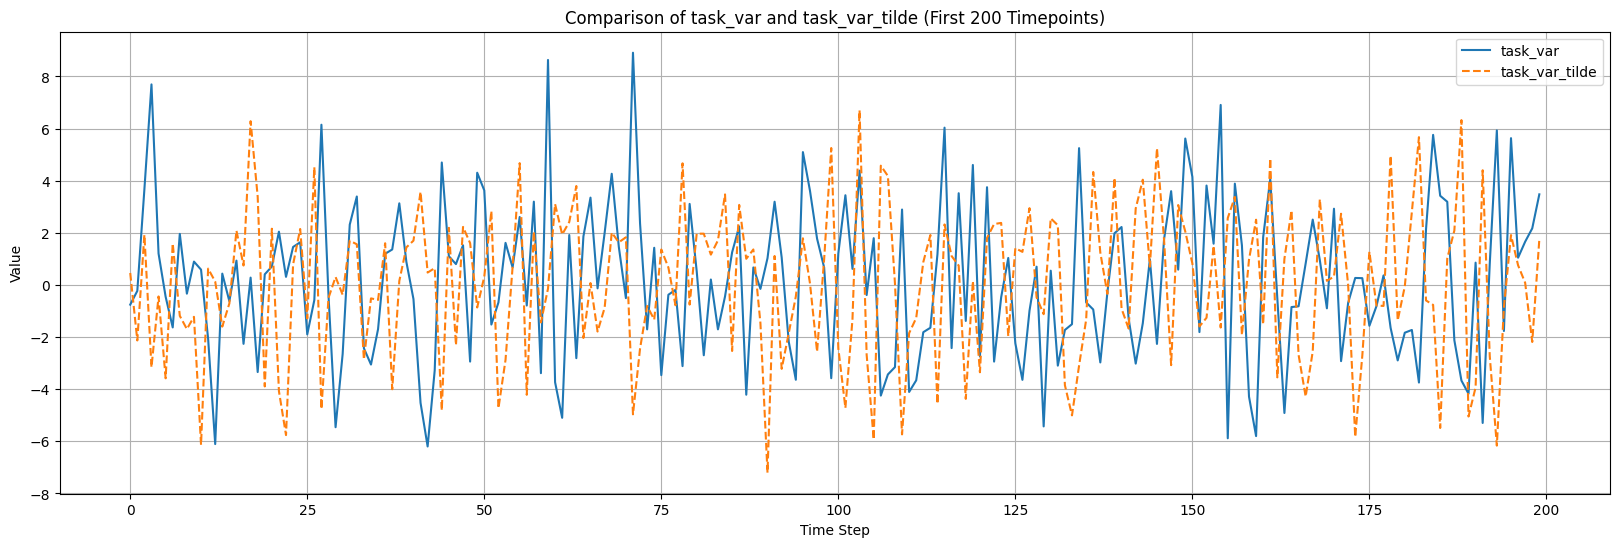

r^2 between task_var and task_var_tilde: -1.470344820511571


In [7]:
from sklearn.metrics import r2_score
# visualize
plt.figure(figsize=(20, 6))
plt.plot(task_var[:200], label='task_var')
plt.plot(task_var_tilde[:200], label='task_var_tilde', linestyle='--')
plt.xlabel('Time Step') # Assuming an underlying time or step index
plt.ylabel('Value')
plt.title('Comparison of task_var and task_var_tilde (First 200 Timepoints)')
plt.legend()
plt.grid(True)
plt.show()

# get r^2 between task_var and task_var_tilde
r2 = r2_score(task_var, task_var_tilde)
print(f"r^2 between task_var and task_var_tilde: {r2}")


### With random initialization in model weights, as baseline

[0 3 1 2] [0.45390279 0.12280213 0.34447091 0.23522595]


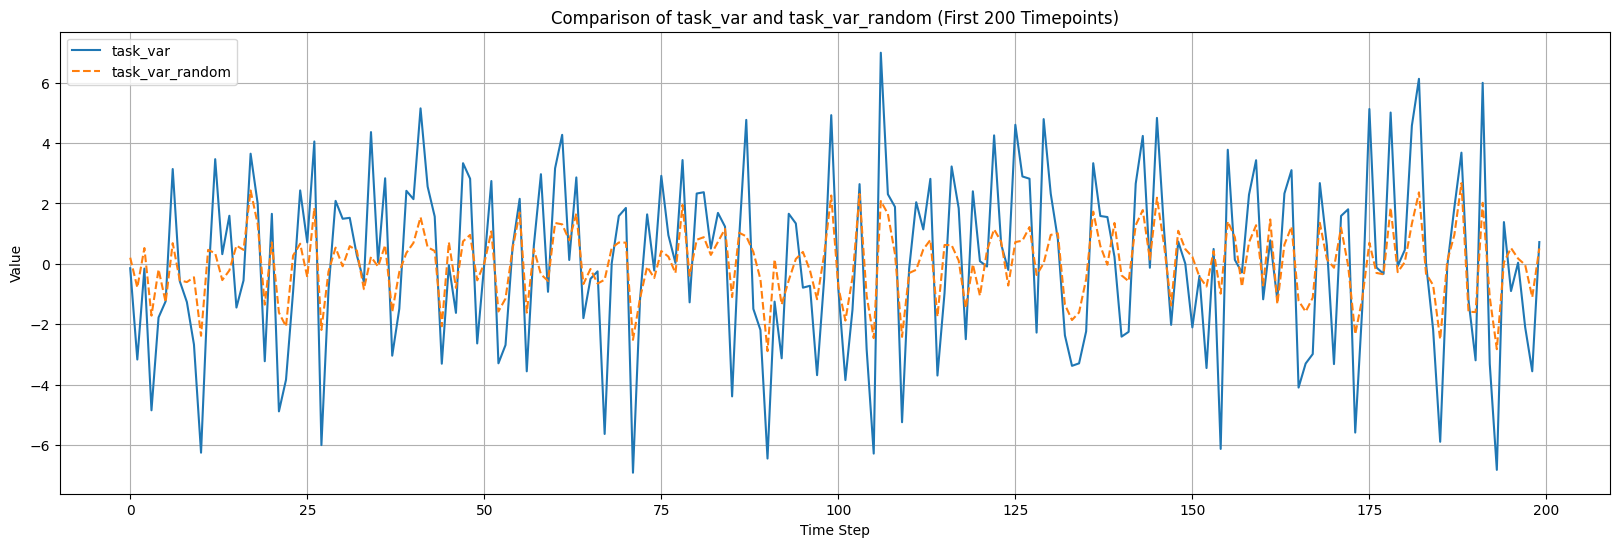

r^2 between task_var and task_var_random: 0.5333081849867995


In [ ]:
# model = SangerNetwork(input_size=N, output_size=m, learning_rate=0.01)
# model = OneShotLeenCompletePCA(**model_paras)
# model = LeenCompletePCA(**_model_paras)
# model = OneShotLeenReislebenPCA(**model_paras)
model = OjaNetwork(**model_paras)
Y_output_random = model.transform(X_before)

order, sim, _ = best_match_align_eigenvectors(model.W, V=V, eigenvectors=pcs)
print(order, sim)

signs = sign_check(Y_output_random, scores, order)
# Apply sign corrections
Y_output_signed_random = Y_output_random * signs[None, :]
# Now compute task variable with sign-corrected output
task_var_random = np.dot(Y_output_signed_random, params)

# visualize
plt.figure(figsize=(20, 6))
plt.plot(task_var[:200], label='task_var')
plt.plot(task_var_random[:200], label='task_var_random', linestyle='--')
plt.xlabel('Time Step') # Assuming an underlying time or step index
plt.ylabel('Value')
plt.title('Comparison of task_var and task_var_random (First 200 Timepoints)')
plt.legend()
plt.grid(True)
plt.show()

# get r^2 between task_var and task_var_random
r2 = r2_score(task_var, task_var_random)
print(f"r^2 between task_var and task_var_random: {r2}")

### Chance level exploration with random vectors

In [10]:
from hebbian.utils import pca_topk
from scipy.stats import pearsonr
from hebbian.utils import best_match_align_timeseries



def random_projection_chance_corr1(X, n_samples=1000, seed=None):
    """
    Calculate the expected absolute correlation between a random projection 
    of X and the PC projections of X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    n_samples : int, default=1000
        Number of random vectors to sample for Monte Carlo estimation
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation between random projection and PC projections
    std_corr : float
        Standard deviation of correlations (for reference)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PCs
    _, _, PC_scores = pca_topk(X, d, center=True)
    print(f"shape of PC_scores: {PC_scores.shape}")
    
    # Sample random unit vectors
    rng = np.random.default_rng(seed)
    correlations = []
    
    for _ in range(n_samples):
        # Random unit vector in d-dimensional space
        w = rng.normal(size=d)
        w = w / (np.linalg.norm(w) + 1e-12)
        
        # Project X onto random direction
        y_random = Xc @ w
        
        # Compute correlation with each PC
        pc_corrs = []
        # print(f"shape of y_random: {y_random.shape}")
        
        # for j in range(min(d, PC_scores.shape[1])):
        # for j in range(2):
        # calculate the covariance between y_random and PC_scores[:, 0]
        cov = np.cov(y_random, PC_scores[:, 0])/np.cov(PC_scores[:, 0], PC_scores[:, 0])
        # pc_corrs.append(abs(r))
        pc_corrs.append(abs(cov[0, 1]))

        
        # Take max correlation (best match, like Hungarian algorithm does)
        correlations.append(max(pc_corrs))
    
    return np.mean(correlations), np.std(correlations)


def random_projection_chance_corr(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Calculate the expected absolute correlation between random projections 
    of X and the PC projections of X, using the same matching procedure
    as the actual analysis (best_match_align_timeseries).
    
    This generates m random unit vectors, projects X onto them, and uses
    Hungarian matching to find optimal alignment with PCs, just like the
    real analysis does.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    m : int, default=2
        Number of random projections (should match output_dim of your model)
    n_samples : int, default=1000
        Number of random vector sets to sample for Monte Carlo estimation
    metric : {"corr", "cosine"}, default="corr"
        Metric to use (should match what you use in best_match_align_timeseries)
    absolute : bool, default=True
        Whether to use absolute correlations (should match your usage)
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation after optimal matching
    std_corr : float
        Standard deviation of correlations (for reference)
    all_corrs : ndarray, shape (n_samples, m)
        All correlation values from each trial (for distribution analysis)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PC scores (top m PCs)
    _, _, PC_scores = pca_topk(X, d, center=True)
    PC_scores_m = PC_scores[:, :m]  # Use only top m PCs
    
    # Sample random projections
    rng = np.random.default_rng(seed)
    all_similarities = []
    
    for trial in range(n_samples):
        # Generate m random unit vectors in d-dimensional space
        W_random = rng.normal(size=(m, d))
        # Normalize each row to unit length
        W_random = W_random / (np.linalg.norm(W_random, axis=1, keepdims=True) + 1e-12)
        
        # Project X onto random directions: Y_random = Xc @ W_random.T
        # Shape: (n, d) @ (d, m) = (n, m)
        Y_random = Xc @ W_random.T
        
        # Use the same matching procedure as actual analysis
        perm, similarity, _, _ = best_match_align_timeseries(
            Y_random, PC_scores_m, 
            metric=metric, 
            absolute=absolute
        )
        
        # similarity is already the matched correlations
        all_similarities.append(similarity)
    
    all_similarities = np.array(all_similarities)  # Shape: (n_samples, m)
    
    # Compute statistics
    expected_corr = np.mean(all_similarities)
    std_corr = np.std(all_similarities)
    
    return expected_corr, std_corr, all_similarities


def random_projection_chance_corr_per_pc(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Same as random_projection_chance_corr but returns per-PC statistics.
    
    Returns
    -------
    expected_corr_per_pc : ndarray, shape (m,)
        Expected correlation for each PC (after sorting by PC order)
    std_corr_per_pc : ndarray, shape (m,)
        Standard deviation for each PC
    """
    expected_corr, std_corr, all_similarities = random_projection_chance_corr(
        X, m, n_samples, metric, absolute, seed
    )
    
    # Sort similarities by PC order (they're already matched, but we want PC1, PC2, ...)
    # The similarities are already optimally matched, so we sort them
    all_similarities_sorted = np.sort(all_similarities, axis=1)  # Sort each row
    
    expected_corr_per_pc = np.mean(all_similarities_sorted, axis=0)
    std_corr_per_pc = np.std(all_similarities_sorted, axis=0)
    
    return expected_corr_per_pc, std_corr_per_pc, all_similarities_sorted



def analytical_chance_corr(input_dim):
    """
    Analytical approximation for expected correlation between random projection
    and PC projection, assuming isotropic data (all eigenvalues equal).
    
    This is a simplified case. For non-isotropic data, use random_projection_chance_corr.
    
    Parameters
    ----------
    input_dim : int
        Input dimensionality
        
    Returns
    -------
    float 
        Expected absolute correlation (approximate)
    """
    # For isotropic case, this reduces to the random vector chance level
    # For non-isotropic, it's more complex and depends on eigenvalue distribution
    return np.sqrt(2 / (np.pi * input_dim))

In [11]:
print(f"Analytical chance correlation: {analytical_chance_corr(N):.3f}")

Analytical chance correlation: 0.199


In [12]:
from hebbian.utils import generate_covariance_matrix
for i in range(2, 10, 1):
    N = i
    m = 2
    phi_deg = 45.0
    n_samples = 10001
    # get /sigma
    Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
    Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)
    print(f" input dimension = {N}")
    print(f"shape of X_before: {X_before.shape}")
    # In Y_aligned_training_testing_online or similar:
    expected_corr, std_corr = random_projection_chance_corr1(X_before, n_samples=1000)
    print(f"Expected chance correlation: {expected_corr:.3f} ± {std_corr:.3f}")

NameError: name 'rotate_cov_nd' is not defined

In [ ]:
# In your notebook or analysis:

# Or get per-PC statistics
expected_per_pc, std_per_pc, _ = random_projection_chance_corr_per_pc(
    X_before, m=2, n_samples=1000
)
print(f"Expected chance correlation per PC: PC1={expected_per_pc[0]:.3f}, PC2={expected_per_pc[1]:.3f}")